# EE267 Spring 2025 Term Project: Swimmer Segmentation and Pose Estimation

## Objective
Articial Intelligence (AI) has transformed computer vision, enabling machines to interpret visual data
much like humans. Two critical techniques in this field are image segmentation and human pose
estimation. Image segmentation isolates objects from their backgrounds, essential for tasks like sports
analysis and medical imaging. Human pose estimation, on the other hand, detects body joints and
movement, providing valuable insights for elds such as biomechanics and augmented reality.

In this assignment, we will do the following:
1. Segment the swimmer from the background using Meta's Segment Anything Model (SAM).
2. Detect and label the swimmer's joints using a human pose estimation model of your choice
(either YOLO or Meta Sapiens).

## Experiment

### Task 0: Data Pre-processing

Complete Guide to Image Preprocessing Techniques in Python: https://medium.com/@maahip1304/the-complete-guide-to-image-preprocessing-techniques-in-python-dca30804550c

Pre-Processing for Image Segmentation using Torchvision: https://pytorch.org/vision/master/auto_examples/transforms/plot_transforms_e2e.html (more up-to-date)

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision.transforms.v2 as T
from torchvision.transforms.functional import to_pil_image
import kornia as K

# Data types
from typing import List
from torch import Tensor
from cv2 import VideoCapture
from torchvision.transforms.v2._container import Compose

In [2]:
# Image dataset folder paths
SWIM_VIDEO_FOLDER = 'data/Swim Videos/'
INPUT_IMAGES_FOLDER = 'data/input/'
SEGMENTED_IMAGES_FOLDER = 'data/segmented/'
KEYPOINTS_FOLDER = 'data/keypoints/'

# Image variables
IMAGE_SIZE = 256

#### Video Pre-processing

In [3]:
def preprocess_video(video_path: VideoCapture, frame_transforms: Compose = None, max_frames: int = None) -> Tensor:
    """Pre-process video frame by frame based on provided transforms

    Args:
        video_path (VideoCapture): path to video file to pre-process
        frame_transforms (Compose): transforms to apply on each frame
        max_frames (int, optional): maximum number of frames to process. Defaults to None.

    Returns:
        Tensor: pre-processed video
    """
    cap = cv2.VideoCapture(SWIM_VIDEO_FOLDER + video_path)
    frames = []
    count = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret or (max_frames and count >= max_frames):
            break
        
        # IMAGE PRE-PROCESSING MAIN
        # --- 1. Convert BGR images to RGB ---
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # --- 2. Convert image array to PyTorch tensor: (H, W, C) -> (C, H, W) ---
        frame_tensor = T.ToTensor()(frame_rgb)  # Shape: (C, H, W)

        # --- 3. Apply Pre-processing pipeline for each frame
        if frame_transforms:
            frame_tensor = frame_transforms(frame_tensor)        # IMAGE TRANSFORMS
        frames.append(frame_tensor)
        count += 1
    
    cap.release()       # Close video reading
    
    # Batch processed video into correct shape for feeding into computer vision models
    # TODO: MAY NOT NEED TO DO PERMUTATION. MAY BE ABLE TO KEEP SHAPE (T, C, H, W). MORE INTUITIVE IMO
    video_tensor = torch.stack(frames)      # Shape: (T, C, H, W)
    return video_tensor.permute(1, 0, 2, 3) # Shape: (C, T, H, W)

In [ ]:
def show_frames(video_tensor: Tensor, title: str, detransforms: Compose = None, frame_indices: List[int] = None, ncols: int = 4) -> None:
    """Function to plot video frames in a grid.

    Parameters:
        video_tensor (Tensor): Video tensor of shape (C, T, H, W)
        title (str): Title of video
        detransforms (Compose): Denormalization transforms to apply to each frame
        frame_indices (List[int]): List of frame indices to visualize
        ncols (int): Number of columns in the subplot grid
    """
    C, T, H, W = video_tensor.shape

    # Default to first 8 frames
    if frame_indices is None:
        frame_indices = list(range(min(8, T)))

    # Set up subplots
    n_frames = len(frame_indices)
    nrows = (n_frames + ncols - 1) // ncols

    fig, axs = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axs = axs.flatten()

    # Plot frames
    for i, idx in enumerate(frame_indices):
        img = video_tensor[:, idx, :, :]
        if detransforms:
            img = detransforms(img).clamp(0, 1) # Denormalize image
        axs[i].imshow(to_pil_image(img))
        axs[i].set_title(f"Frame {idx}")
        axs[i].axis("off")

    # Hide unused subplots
    for j in range(i + 1, len(axs)):
        axs[j].axis("off")

    if title:
        plt.suptitle(title, fontsize=16, y=1)

    plt.tight_layout()
    plt.show()

def get_frame(video_tensor: Tensor, idx: int = 0) -> Tensor:
    """
    Get a specific frame from a video tensor.
    
    Args:
        video_tensor (Tensor): The video tensor.
        idx (int): The index of the frame to extract.
        
    Returns:
        Tensor: The extracted frame.
    """
    return video_tensor[:, idx, :, :]

def show_image(image: Tensor, detransform: Compose = None) -> None:
    """Denormalize and plot an image.

    Args:
        image (Tensor): Image to denormalize and plot
        detransform (Compose): Denormalization transforms to apply to the image
    """
    plt.figure(figsize=(10, 10))
    if detransform:
        image = detransform(image).clamp(0, 1) # Denormalize image
    plt.imshow(to_pil_image(image))
    plt.axis("off")
    plt.show()

In [5]:
def remove_blue_from_image(image: torch.Tensor) -> Tensor:
    """Removes blue from an image by manipulating the hue channel in HSV space."""

    # Convert to HSV
    hsv_image = K.color.rgb_to_hsv(image.float() / 255.0)  # Assuming image is in range [0, 255]

    # Manipulate the hue channel (example: shift blue hues)
    hue_channel = hsv_image[:, 0, :, :] # Extract the hue channel
    blue_mask = (hue_channel > 0.5) & (hue_channel < 0.9) # Define a mask for blue hues
    hue_channel[blue_mask] = 0  # Shift blue hues to a different value
    hsv_image[:, 0, :, :] = hue_channel  # Update hue channel in HSV image

    # Convert back to RGB
    rgb_image = K.color.hsv_to_rgb(hsv_image)

    return rgb_image * 255.0  # Scale back to [0, 255]

In [ ]:
# Basic Pre-processing pipeline for each frame
basic_frame_transforms = T.Compose([
    T.Resize((389, 389)),
    T.CenterCrop(389),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Advanced Pre-processing pipeline for each frame
advanced_frame_transforms = T.Compose([
    T.Resize((389, 389)),
    T.CenterCrop(389),
    
    # Bilateral (edge‐preserving) smoothing
    T.Lambda(lambda x: K.filters.bilateral_blur(x.unsqueeze(0), kernel_size=(3,3), sigma_color=0.1, sigma_space=(1.0, 1.0)).squeeze(0)),

    # Sobel edge‐detection
    # T.Lambda(lambda x: K.filters.spatial_gradient(x.unsqueeze(0), mode='sobel', order=1).squeeze(0)),

    # Adjust contrast
    T.Lambda(lambda x: K.enhance.adjust_contrast(x.unsqueeze(0), 1.5).squeeze(0)),

    # Image sharpening
    T.Lambda(lambda x: K.enhance.sharpness(x.unsqueeze(0), 2.0).squeeze(0)),

    # Remove blue from image
    # T.Lambda(lambda x: remove_blue_from_image(x.unsqueeze(0)).squeeze(0)),

    T.ToDtype(torch.float32, scale=True),

    T.Normalize(mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225]),
])

# Denormalization of tensor transforms
frame_detransforms = T.Compose([
    T.Normalize(mean=[0., 0., 0.], std=[1/0.229, 1/0.224, 1/0.225]),
    T.Normalize(mean=[-0.485, -0.456, -0.406], std=[1., 1., 1.])
])

In [ ]:
# Pre-process swim videos
back_video = preprocess_video('back-training.mp4', advanced_frame_transforms, max_frames=64)
breast_video = preprocess_video('breast-training.mp4', advanced_frame_transforms, max_frames=32)
fly_video = preprocess_video('fly-training.mp4', advanced_frame_transforms, max_frames=32)
free_video = preprocess_video('freestyle-training.mp4', advanced_frame_transforms, max_frames=32)

print(f"Loaded back-training.mp4: shape = {back_video.shape}")
print(f"Loaded breast-training.mp4: shape = {breast_video.shape}")
print(f"Loaded fly-training.mp4: shape = {fly_video.shape}")
print(f"Loaded freestyle-training.mp4: shape = {free_video.shape}")

/Users/ricktruong/Desktop/Coding Coursework/SJSU/EE 267/Project/venv/lib/python3.9/site-packages/torchvision/transforms/v2/_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(


Loaded back-training.mp4: shape = torch.Size([3, 64, 389, 389])
Loaded breast-training.mp4: shape = torch.Size([3, 32, 389, 389])
Loaded fly-training.mp4: shape = torch.Size([3, 32, 389, 389])
Loaded freestyle-training.mp4: shape = torch.Size([3, 32, 389, 389])


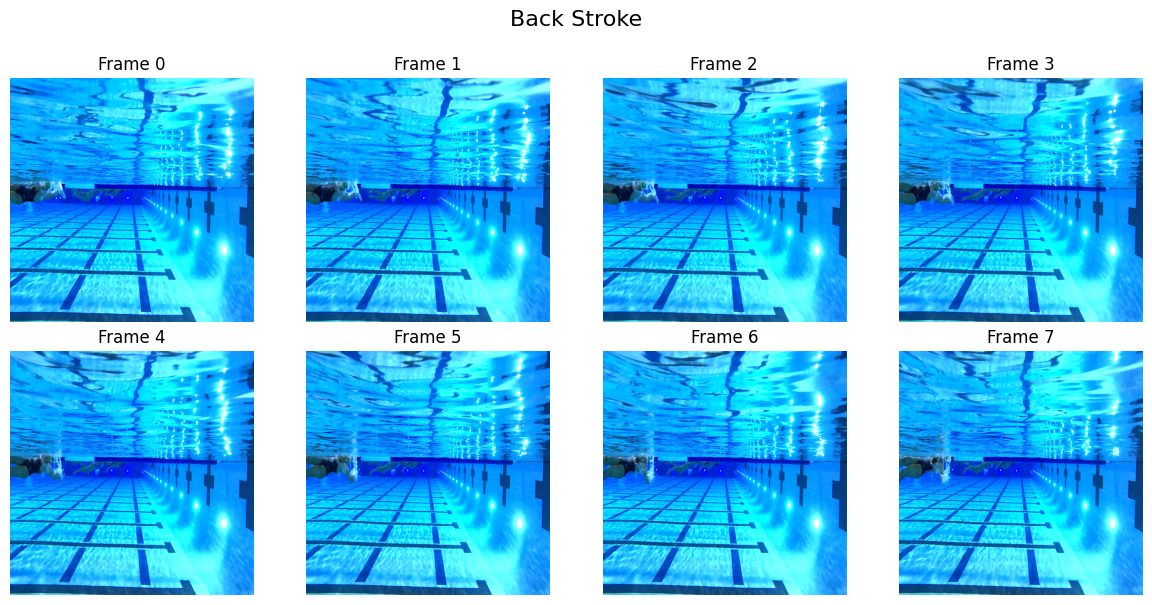

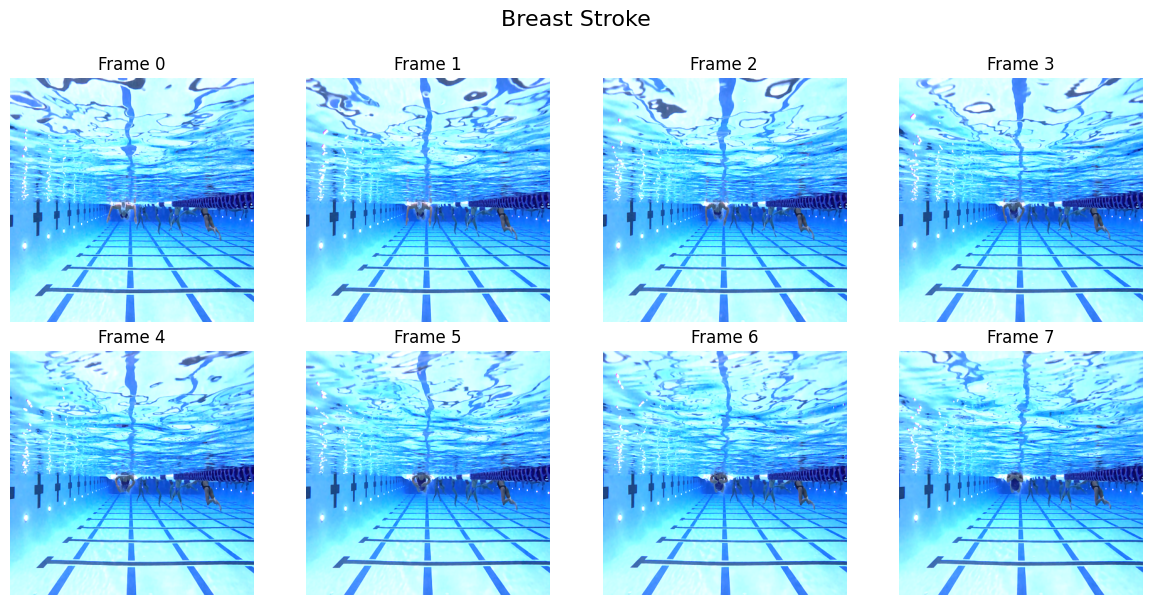

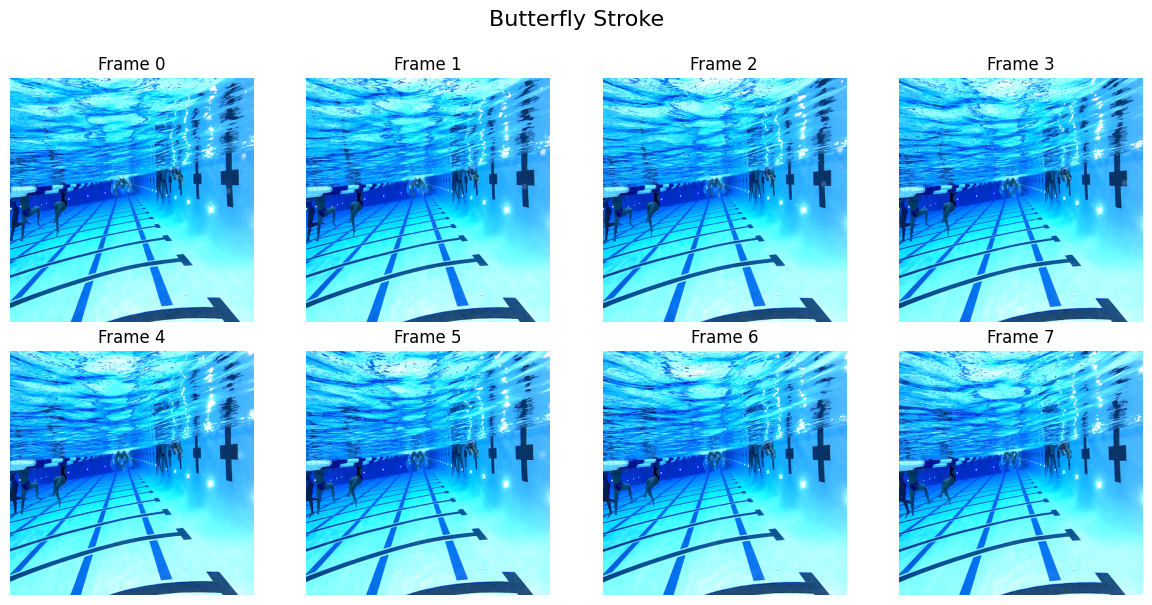

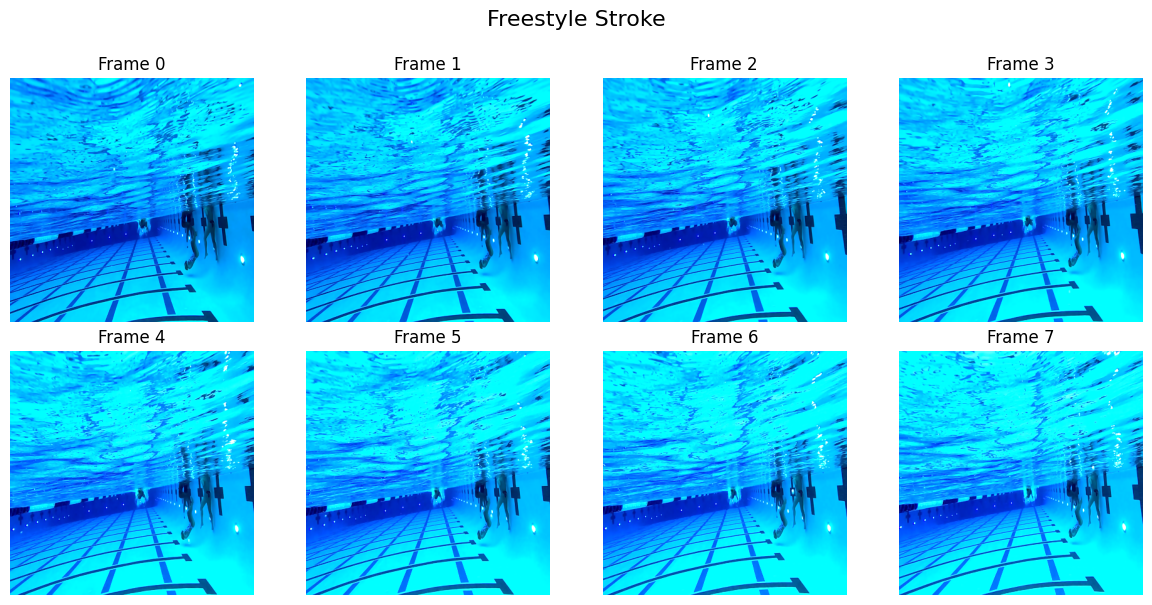

In [ ]:
# Visualize processed videos
show_frames(back_video, title='Back Stroke', detransforms=frame_detransforms)
show_frames(breast_video, title='Breast Stroke', detransforms=frame_detransforms)
show_frames(fly_video, title='Butterfly Stroke', detransforms=frame_detransforms)
show_frames(free_video, title='Freestyle Stroke', detransforms=frame_detransforms)

#### Advanced Image Pre-Processing (if needed)

### Task 1: Swimmer Segmentation with SAM
Description:

Use Meta’s SAM model to isolate the swimmer from each frame provided.

Instructions:
1. Load the provided dataset of swimmer images.
2. Apply SAM to each image to segment the swimmer, separating them from the background.
3. Save the segmented images for the next task.

Meta SAM Github: https://github.com/facebookresearch/segment-anything

In [9]:
# Import libraries
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import supervision as sv

# Data Types
from matplotlib.axes import Axes

# Check if GPU is available for PyTorch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [11]:
# Meta Segment Anything Model (SAM) variables
MODEL_CHECKPOINT_LARGE = 'models/sam_vit_h_4b8939.pth'
SAM_TYPE_LARGE = 'vit_h'

MODEL_CHECKPOINT_SMALL = 'models/sam_vit_b_01ec64.pth'
SAM_TYPE_SMALL = 'vit_b'

# Load Meta SAM variant
sam = sam_model_registry[SAM_TYPE_LARGE](checkpoint=MODEL_CHECKPOINT_LARGE)
sam.to(device=device)
print("SAM Model loaded")

SAM Model loaded


In [12]:
# Initialize Automatic Mask Generator
mask_generator = SamAutomaticMaskGenerator(
    sam, 
    points_per_side=32, 
    pred_iou_thresh=0.88, 
    stability_score_thresh=0.95, 
    min_mask_region_area=100
)

In [61]:
def segment_video(video_tensor: Tensor, detransforms: Compose = None, max_frames: int = 32) -> None:
    """Segment video frames using SAM and display the results.
    
    Args:
        video_tensor (Tensor): Video tensor of shape (C, T, H, W)
        detransforms (Compose): Denormalization transforms to apply to each frame
        max_frames (int): Maximum number of frames to process
    """
    for idx in range(min(video_tensor.shape[1], max_frames)):
        # Detransform video frame tensors
        image_rgb = get_frame(back_video, idx=idx)
        if detransforms:
            image_rgb = frame_detransforms(image_rgb)
        print(image_rgb.shape)

        # Convert to numpy array/CV2 format
        image_rgb = image_rgb.permute(1, 2, 0).numpy()
        image_rgb = (image_rgb * 255).astype(np.uint8)
        image_gbr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

        # Generate masks for the image
        masks = mask_generator.generate(image_rgb)
        detections = sv.Detections.from_sam(masks)
        
        # Annotate the image with the generated masks
        mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
        annotated_image = mask_annotator.annotate(scene=image_gbr, detections=detections)
        
        # Display the annotated image
        show_image(annotated_image)
        
        # Save annotated image
        cv2.imwrite(SEGMENTED_IMAGES_FOLDER + f'back_{idx}.png', annotated_image)

torch.Size([3, 389, 389])


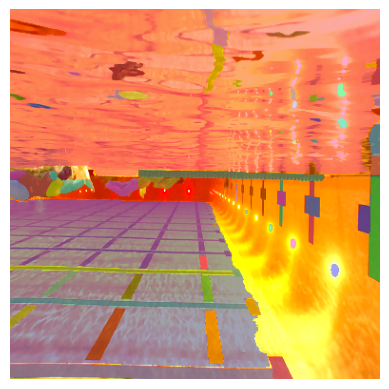

torch.Size([3, 389, 389])


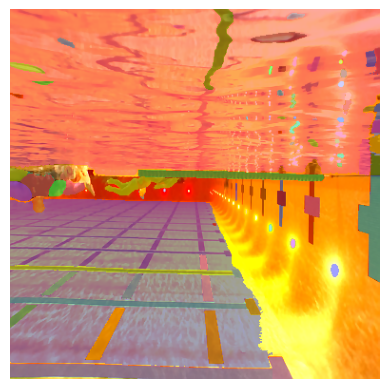

torch.Size([3, 389, 389])


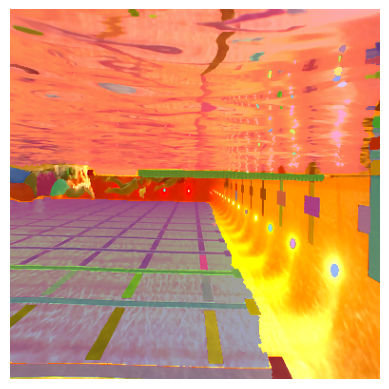

torch.Size([3, 389, 389])


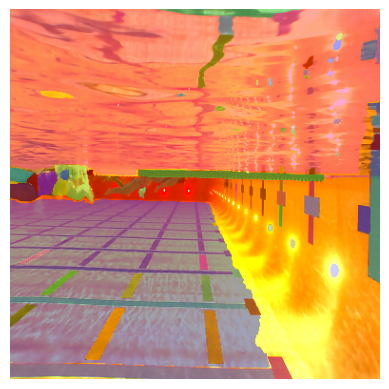

torch.Size([3, 389, 389])


In [ ]:
segment_video(back_video, detransforms=frame_detransforms, max_frames=32)

### Task 2: Pose Estimation on the Segmented Swimmer

Description:

With the segmented swimmer images, utilize a human pose estimation model to
detect the swimmer’s joints.

Model Options:
1. YOLO (congured for pose estimation).
2. Meta Sapiens

Instructions:
1. Choose either YOLO or Meta Sapiens for pose estimation.
2. Run the selected model on the segmented images to identify key joint positions.
3. Save images with overlaid joint positions and export joint coordinates for each frame.


Ultralytics YOLOv11 Pose Estimation Docs: https://docs.ultralytics.com/tasks/pose/

In [ ]:
# Import libraries
from ultralytics import YOLO

In [ ]:
# Initialize Pose Estimation Model
model = YOLO('models/yolo11n-pose.pt')

In [ ]:
# Identify key joint positions
results = model.track('back_training.mp4', show=True, save=True)

FileNotFoundError: back_training.mp4 does not exist

In [ ]:
# Overlay images with joint positions

In [ ]:
# Save overlaid images, save keypoint coordinates in csv file